In [2]:
import pickle 
from pathlib import Path 
import copy 
import open3d as o3d 
import numpy as np 
# from aligner import Aligner
import gopropy
import matplotlib.pyplot as plt

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


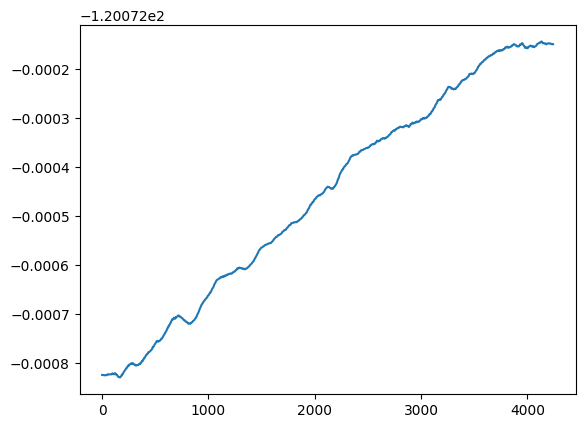

In [23]:
telemetry = gopropy.load('/home/ape/Documents/MapperGoProVids/tahoe_ridge_1.MP4')
gps = telemetry.get_stream('GPS (Lat., Long., Alt., 2D speed, 3D speed)')
gps_df = gps.to_dataframe()
plt.plot(gps_df['lon'])


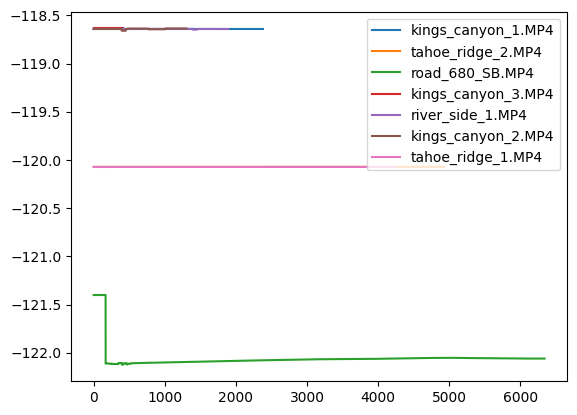

In [15]:
folder = Path("/home/ape/Documents/MapperGoProVids")
for file in folder.glob("*.MP4"):
    telemetry = gopropy.load(file)
    gps = telemetry.get_stream('GPS (Lat., Long., Alt., 2D speed, 3D speed)')
    gps_df = gps.to_dataframe()
    plt.plot(gps_df['lon'], label = file.name)
plt.legend()
plt.show()


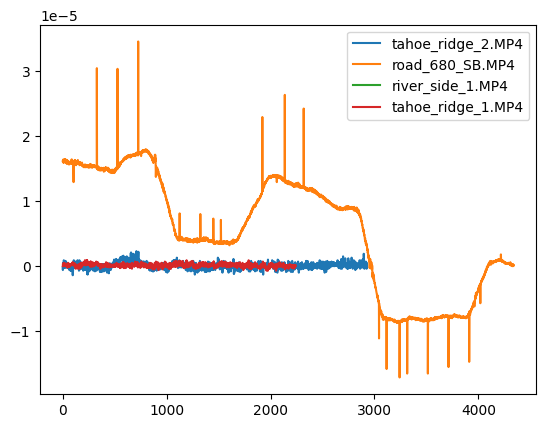

In [8]:
folder = Path("/home/ape/Documents/MapperGoProVids")
for file in folder.glob("*.MP4"):
    if 'kings_canyon' in file.name:
        continue
    telemetry = gopropy.load(file)
    gps = telemetry.get_stream('GPS (Lat., Long., Alt., 2D speed, 3D speed)')
    gps_df = gps.to_dataframe()
    plt.plot(np.diff(gps_df['lon'][2000:]), label = file.name)
plt.legend()
plt.show()


In [3]:
# load ply files in folder 

folder = Path("/home/ape/repos/must3rdemo/must3r/test_dir")
ply_files = list(folder.glob("*.ply"))

# load ply files 
pcds = [o3d.io.read_point_cloud(ply_file) for ply_file in ply_files]
source = pcds[0]
target = pcds[3]

In [ ]:
def align_sequential_icp(point_clouds:list[o3d.geometry.PointCloud])->list[o3d.geometry.PointCloud]:
    # align the pointclouds sequentially using the ICP algorithm 
    for i in range(len(point_clouds) - 1):
        source = point_clouds[i]
        target = point_clouds[i + 1]
        # do global registration first
        source, target, source_down, target_down, source_fpfh, target_fpfh = prepare_dataset(0.05, source, target)
        initial_global_registration = execute_global_registration(source_down, target_down, source_fpfh, target_fpfh, 0.05)

        # then do ICP
        icp_result = o3d.pipelines.registration.registration_icp(
            source, target, 0.075, initial_global_registration.transformation,
            o3d.pipelines.registration.TransformationEstimationPointToPoint())
        # return icp_result
        # print(icp_result)
        # print(icp_result.transformation)
        point_clouds[i + 1] = point_clouds[i + 1].transform(icp_result.transformation)
        # point_clouds[i + 1] = icp_result.transformation @ point_clouds[i + 1]

        
    return point_clouds
icp_result = align_sequential_icp(pcds)

:: Load two point clouds and disturb initial pose.
[Open3D WARNING] GLFW initialized for headless rendering.
[Open3D WARNING] GLFW Error: OSMesa: Library not found
[Open3D WARNING] Failed to create window
[Open3D WARNING] [DrawGeometries] Failed creating OpenGL window.
:: Downsample with a voxel size 0.050.
:: Estimate normal with search radius 0.100.
:: Compute FPFH feature with search radius 0.250.
:: Downsample with a voxel size 0.050.
:: Estimate normal with search radius 0.100.
:: Compute FPFH feature with search radius 0.250.
:: RANSAC registration on downsampled point clouds.
   Since the downsampling voxel size is 0.050,
   we use a liberal distance threshold 0.075.
:: Load two point clouds and disturb initial pose.
[Open3D WARNING] GLFW initialized for headless rendering.
[Open3D WARNING] GLFW Error: OSMesa: Library not found
[Open3D WARNING] Failed to create window
[Open3D WARNING] [DrawGeometries] Failed creating OpenGL window.
:: Downsample with a voxel size 0.050.
:: Estim

In [1]:
def draw_registration_result(source, target, transformation, override_color=False):
    source_temp = copy.deepcopy(source)
    target_temp = copy.deepcopy(target)
    if override_color:
        source_temp.paint_uniform_color([1, 0.706, 1])
        target_temp.paint_uniform_color([0, 0.651, 1])
    source_temp.transform(transformation)
    
    o3d.visualization.draw_geometries([source_temp, target_temp],
                                    #   zoom=0.4459,
                                    #   front=[0.9288, -0.2951, -0.2242],
                                    #   lookat=[1.6784, 2.0612, 1.4451],
                                    #   up=[-0.3402, -0.9189, -0.1996], 
                                    )
def execute_global_registration(source_down, target_down, source_fpfh,
                                target_fpfh, voxel_size):
    distance_threshold = voxel_size * 1.5
    print(":: RANSAC registration on downsampled point clouds.")
    print("   Since the downsampling voxel size is %.3f," % voxel_size)
    print("   we use a liberal distance threshold %.3f." % distance_threshold)
    result = o3d.pipelines.registration.registration_ransac_based_on_feature_matching(
        source_down, target_down, source_fpfh, target_fpfh, True,
        distance_threshold,
        o3d.pipelines.registration.TransformationEstimationPointToPoint(False),
        3, [
            o3d.pipelines.registration.CorrespondenceCheckerBasedOnEdgeLength(
                0.9),
            o3d.pipelines.registration.CorrespondenceCheckerBasedOnDistance(
                distance_threshold)
        ], o3d.pipelines.registration.RANSACConvergenceCriteria(100000, 0.999))
    return result
def preprocess_point_cloud(pcd, voxel_size):
    print(":: Downsample with a voxel size %.3f." % voxel_size)
    pcd_down = pcd.voxel_down_sample(voxel_size)

    radius_normal = voxel_size * 2
    print(":: Estimate normal with search radius %.3f." % radius_normal)
    pcd_down.estimate_normals(
        o3d.geometry.KDTreeSearchParamHybrid(radius=radius_normal, max_nn=30))

    radius_feature = voxel_size * 5
    print(":: Compute FPFH feature with search radius %.3f." % radius_feature)
    pcd_fpfh = o3d.pipelines.registration.compute_fpfh_feature(
        pcd_down,
        o3d.geometry.KDTreeSearchParamHybrid(radius=radius_feature, max_nn=100))
    return pcd_down, pcd_fpfh

def prepare_dataset(voxel_size, source,  target):
    print(":: Load two point clouds and disturb initial pose.")


    trans_init = np.asarray([[0.0, 0.0, 1.0, 0.0], [1.0, 0.0, 0.0, 0.0],
                             [0.0, 1.0, 0.0, 0.0], [0.0, 0.0, 0.0, 1.0]])
    source.transform(trans_init)
    draw_registration_result(source, target, np.eye(4))

    source_down, source_fpfh = preprocess_point_cloud(source, voxel_size)
    target_down, target_fpfh = preprocess_point_cloud(target, voxel_size)
    return source, target, source_down, target_down, source_fpfh, target_fpfh

In [5]:
draw_registration_result(source, target, np.eye(4)) 

[Open3D INFO] Window window_0 created.
[Open3D INFO] EGL headless mode enabled.
[Open3D INFO] ICE servers: ["stun:stun.l.google.com:19302", "turn:user:password@34.69.27.100:3478", "turn:user:password@34.69.27.100:3478?transport=tcp"]
[Open3D INFO] Set WEBRTC_STUN_SERVER environment variable add a customized WebRTC STUN server.
[Open3D INFO] WebRTC Jupyter handshake mode enabled.
FEngine (64 bits) created at 0x768519942010 (threading is enabled)
EGL(1.5)
OpenGL(4.1)


KeyboardInterrupt: 

In [7]:
voxel_size = 0.05  # means 5cm for this dataset
source, target, source_down, target_down, source_fpfh, target_fpfh = prepare_dataset(
    voxel_size, source, target)
result_ransac = execute_global_registration(source_down, target_down,
                                            source_fpfh, target_fpfh,
                                            voxel_size)
print(result_ransac)

:: Load two point clouds and disturb initial pose.
:: Downsample with a voxel size 0.050.
:: Estimate normal with search radius 0.100.
:: Compute FPFH feature with search radius 0.250.
:: Downsample with a voxel size 0.050.
:: Estimate normal with search radius 0.100.
:: Compute FPFH feature with search radius 0.250.
:: RANSAC registration on downsampled point clouds.
   Since the downsampling voxel size is 0.050,
   we use a liberal distance threshold 0.075.
RegistrationResult with fitness=1.000000e+00, inlier_rmse=2.204257e-02, and correspondence_set size of 5650
Access transformation to get result.


In [6]:
result_ransac.transformation

array([[ 0.07153736,  0.99738004, -0.01074554, -0.13365817],
       [-0.04328955,  0.01386758,  0.99896632,  0.11365028],
       [ 0.99649808, -0.07099824,  0.04416818, -0.01612404],
       [ 0.        ,  0.        ,  0.        ,  1.        ]])

In [5]:
draw_registration_result(source, target,np.eye(4), override_color=True)

In [9]:
print("Initial alignment")
evaluation = o3d.pipelines.registration.evaluate_registration(
    source, target, threshold, trans_init)
print(evaluation)

Initial alignment


NameError: name 'threshold' is not defined

In [ ]:
print("Apply point-to-point ICP")
reg_p2p = o3d.pipelines.registration.registration_icp(
    source, target, threshold, trans_init,
    o3d.pipelines.registration.TransformationEstimationPointToPoint())
print(reg_p2p)
print("Transformation is:")
print(reg_p2p.transformation)
draw_registration_result(source, target, reg_p2p.transformation)

In [ ]:
reg_p2p = o3d.pipelines.registration.registration_icp(
    source, target, threshold, trans_init,
    o3d.pipelines.registration.TransformationEstimationPointToPoint(),
    o3d.pipelines.registration.ICPConvergenceCriteria(max_iteration=2000))
print(reg_p2p)
print("Transformation is:")
print(reg_p2p.transformation)
draw_registration_result(source, target, reg_p2p.transformation)

In [5]:
import json
import exiftool
def read_exif_data(file_path):
    with exiftool.ExifTool() as et:
        output = et.execute(b"-j", file_path.encode('utf-8'))
        print(output)
        metadata = json.loads(output)  # decode and parse JSON
        return metadata

# Example usage
file = "/home/ape/Documents/MapperGoProVids/tahoe_ridge_1.MP4"


exif_data = read_exif_data(file)
exif_data

[{
  "SourceFile": "/home/ape/Documents/MapperGoProVids/tahoe_ridge_1.MP4",
  "ExifTool:ExifToolVersion": 12.40,
  "ExifTool:Warning": "[minor] The ExtractEmbedded option may find more tags in the media data",
  "File:FileName": "tahoe_ridge_1.MP4",
  "File:Directory": "/home/ape/Documents/MapperGoProVids",
  "File:FileSize": 1750016809,
  "File:FileModifyDate": "2025:07:31 09:24:34-07:00",
  "File:FileAccessDate": "2025:10:25 00:09:22-07:00",
  "File:FileInodeChangeDate": "2025:10:06 19:19:29-07:00",
  "File:FilePermissions": 100755,
  "File:FileType": "MP4",
  "File:FileTypeExtension": "MP4",
  "File:MIMEType": "video/mp4",
  "QuickTime:MajorBrand": "mp41",
  "QuickTime:MinorVersion": "2013.10.18",
  "QuickTime:CompatibleBrands": ["mp41"],
  "QuickTime:MediaDataSize": 1749786018,
  "QuickTime:MediaDataOffset": 36,
  "QuickTime:MovieHeaderVersion": 0,
  "QuickTime:CreateDate": "2025:07:31 16:20:38",
  "QuickTime:ModifyDate": "2025:07:31 16:20:38",
  "QuickTime:TimeScale": 60000,
  "Qu

[{'SourceFile': '/home/ape/Documents/MapperGoProVids/tahoe_ridge_1.MP4',
  'ExifTool:ExifToolVersion': 12.4,
  'ExifTool:Warning': '[minor] The ExtractEmbedded option may find more tags in the media data',
  'File:FileName': 'tahoe_ridge_1.MP4',
  'File:Directory': '/home/ape/Documents/MapperGoProVids',
  'File:FileSize': 1750016809,
  'File:FileModifyDate': '2025:07:31 09:24:34-07:00',
  'File:FileAccessDate': '2025:10:25 00:09:22-07:00',
  'File:FileInodeChangeDate': '2025:10:06 19:19:29-07:00',
  'File:FilePermissions': 100755,
  'File:FileType': 'MP4',
  'File:FileTypeExtension': 'MP4',
  'File:MIMEType': 'video/mp4',
  'QuickTime:MajorBrand': 'mp41',
  'QuickTime:MinorVersion': '2013.10.18',
  'QuickTime:CompatibleBrands': ['mp41'],
  'QuickTime:MediaDataSize': 1749786018,
  'QuickTime:MediaDataOffset': 36,
  'QuickTime:MovieHeaderVersion': 0,
  'QuickTime:CreateDate': '2025:07:31 16:20:38',
  'QuickTime:ModifyDate': '2025:07:31 16:20:38',
  'QuickTime:TimeScale': 60000,
  'QuickT

In [2]:
# Compare the results in two folders side by side, offsetting one set for visual clarity

from pathlib import Path
import open3d as o3d
import numpy as np

# Define the two folders to compare
folder1 = Path("/home/ape/repos/must3rdemo/must3r/test_dir/test_alignment_0.1")
folder2 = Path("/home/ape/repos/must3rdemo/must3r/test_dir/test_alignment/colored_icp_voxel0.1")
# Get the ply files from each folder
ply_files1 = sorted(folder1.glob("*.ply"))
ply_files2 = sorted(folder2.glob("*.ply"))

# Read point clouds
pcds1 = [o3d.io.read_point_cloud(str(ply_file)) for ply_file in ply_files1]
pcds2 = [o3d.io.read_point_cloud(str(ply_file)) for ply_file in ply_files2]

# Offset the second set of point clouds along the X axis for side-by-side comparison
offset = np.array([50.0, 0.0, 0.0])  # Adjust the value as needed for your data
for pcd in pcds2:
    pcd.translate(offset)

print("Showing both results side by side in one window (left: Alignment 1.0, right: Alignment 0.1)")
o3d.visualization.draw_geometries(pcds1 + pcds2, window_name="Side-by-Side Comparison")


Showing both results side by side in one window (left: Alignment 1.0, right: Alignment 0.1)


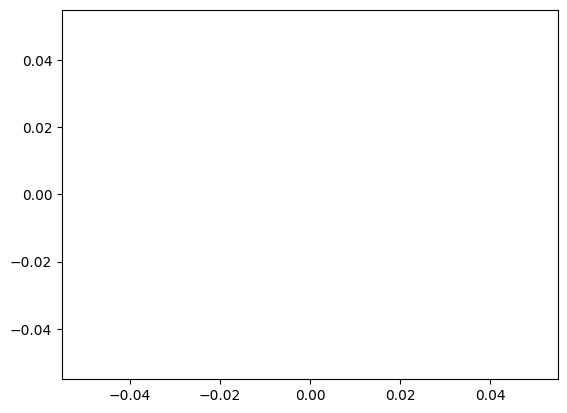

In [9]:
import open3d as o3d
pc = o3d.io.read_point_cloud("data/output_kings_canyon/kings_canyon_orb_slam_20251231_000745/outputs/kings_canyon_1/aligned_pointcloud.ply")
# o3d.visualization.draw_geometries([pc])
# o3d.visualization.draw(pc, point_size=2)
# o3d.visualization.draw_geometries([pc], webgl=True)
# import plotly.graph_objects as go
import numpy as np
from matplotlib import pyplot as plt
points = np.asarray(pc.points)
colors = np.asarray(pc.colors) / 255.0 if pc.has_colors() else None

plt.scatter(points[:, 0], points[:, 1], c=colors, s=2)
plt.show()


In [13]:
pc = o3d.io.read_point_cloud("data/output_kings_canyon/kings_canyon_orb_slam_20251231_000745/outputs/kings_canyon_3/aligned_pointcloud.ply")
points = np.asarray(pc.points)
points

array([[nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan],
       ...,
       [nan, nan, nan],
       [nan, nan, nan],
       [nan, nan, nan]])